In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
df = pd.read_csv('Housing.csv')

In [44]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [45]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [15]:
df.describe(include = 'all')

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545,545,545,545,545,545.000000,545,545
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished
freq,NaN,NaN,NaN,NaN,NaN,468,448,354,520,373,NaN,417,227
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,NaN,NaN,NaN,NaN,NaN,0.693578,NaN,NaN
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,NaN,NaN,NaN,NaN,NaN,0.861586,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [23]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [51]:
df.duplicated().sum()

0

In [50]:
df_copy = df.copy()

In [52]:
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())
    print()

mainroad
['yes' 'no']

guestroom
['no' 'yes']

basement
['no' 'yes']

hotwaterheating
['no' 'yes']

airconditioning
['yes' 'no']

prefarea
['yes' 'no']

furnishingstatus
['furnished' 'semi-furnished' 'unfurnished']



In [53]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

In [54]:
for col in binary_cols:
    df[col] = df[col].map({
        'yes':1,
        'no':0
    })

In [56]:
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True,
    dtype=int
)

In [59]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    i

In [62]:
num_cols = ['price','area','bedrooms','bathrooms','stories','parking']

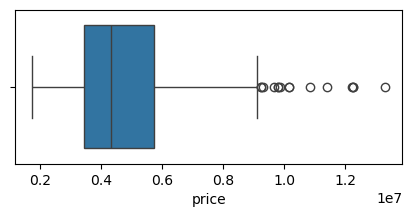

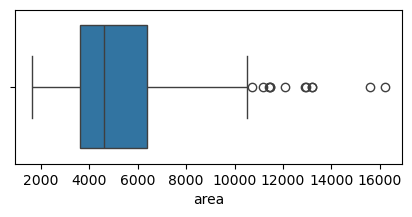

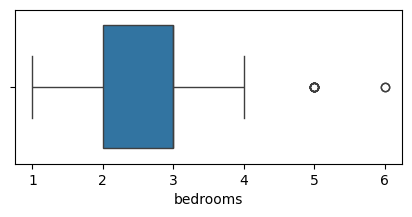

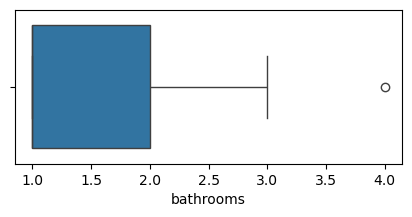

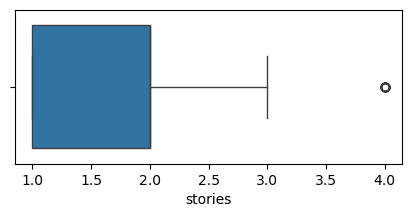

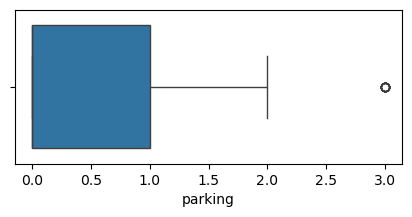

In [68]:
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.show()

In [72]:
df.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862,0.416514,0.326606
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.493434,0.469402
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000


Observation:
- Dataset contains 545 records and no missing values.
- Average house price is ₹47.67 lakhs.
- Price and area distributions are positively skewed, indicating the presence of some premium properties.
- Most houses have 2–3 bedrooms and 1–2 bathrooms.
- Majority of houses are connected to the main road (~86%).
- Guest rooms and hot water heating systems are relatively uncommon.
- Semi-furnished houses are the most common furnishing category.
- Dataset appears clean and suitable for EDA and model building.

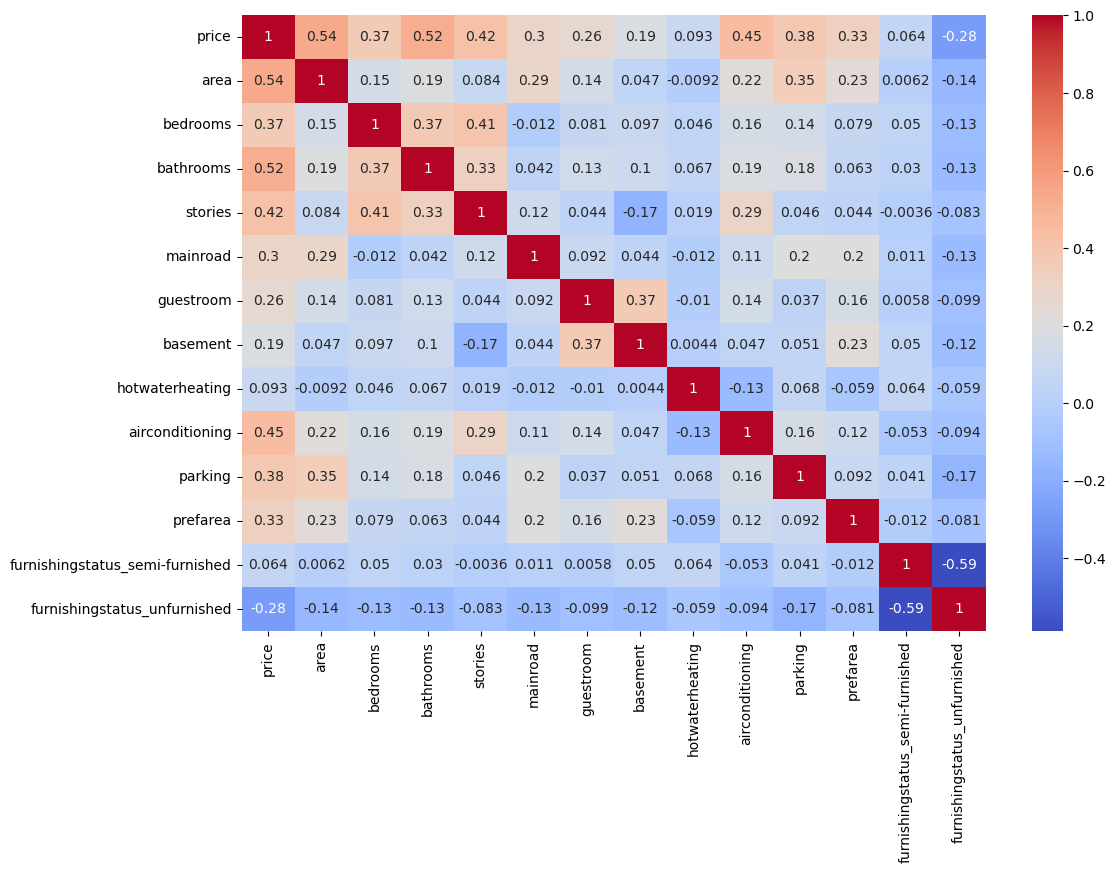

In [73]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

<Axes: xlabel='area', ylabel='price'>

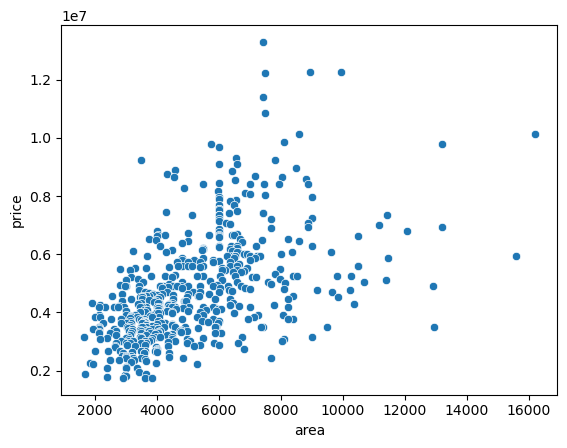

In [74]:
sns.scatterplot(x='area', y='price', data=df)

<Axes: xlabel='bedrooms', ylabel='price'>

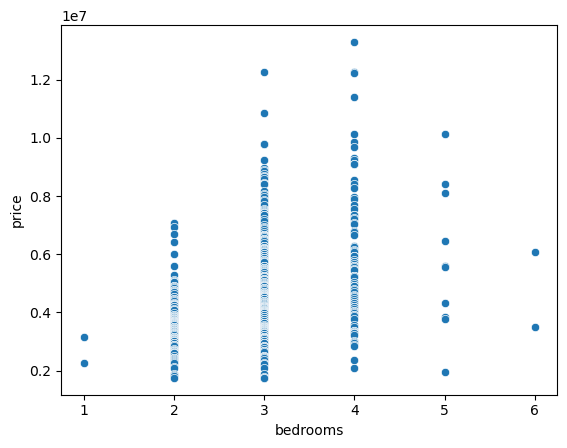

In [75]:
sns.scatterplot(x='bedrooms', y='price', data=df)

<Axes: xlabel='bathrooms', ylabel='price'>

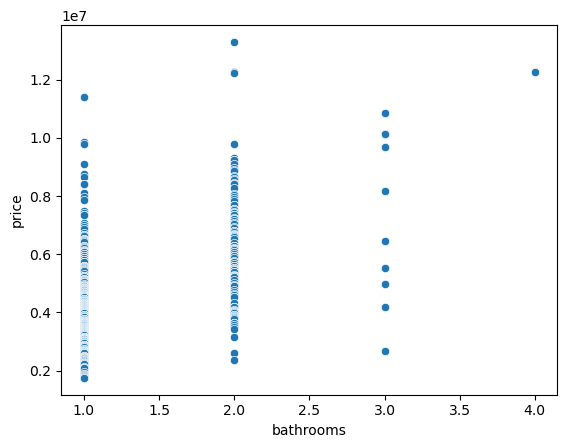

In [76]:
sns.scatterplot(x='bathrooms', y='price', data=df)

<Axes: xlabel='parking', ylabel='price'>

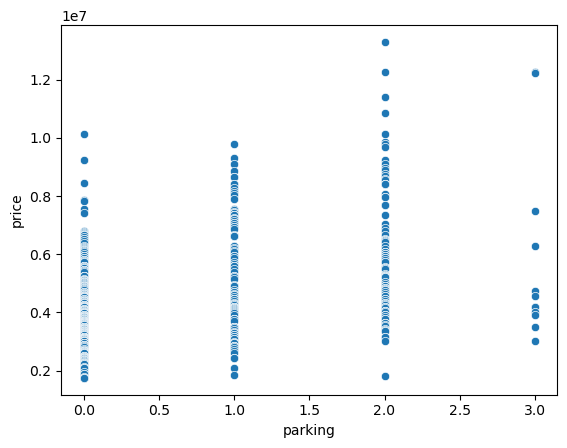

In [77]:
sns.scatterplot(x='parking', y='price', data=df)

Overall EDA Findings:

- Area and bathrooms are the most influential features affecting house price.
- Air conditioning, stories, parking spaces, and number of bedrooms also positively influence price.
- Houses located in preferred areas and connected to the main road tend to be more expensive.
- Unfurnished houses generally have lower prices.
- The relationships between features and price are mostly positive.
- No unusual patterns or unrealistic values were observed in the dataset.

In [80]:
y = df['price']

In [81]:
X = df.drop('price', axis=1)

In [82]:
print(X.head())
print(y.head())

   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  7420         4          2        3         1          0         0   
1  8960         4          4        4         1          0         0   
2  9960         3          2        2         1          0         1   
3  7500         4          2        2         1          0         1   
4  7420         4          1        2         1          1         1   

   hotwaterheating  airconditioning  parking  prefarea  \
0                0                1        2         1   
1                0                1        3         0   
2                0                0        2         1   
3                0                1        3         1   
4                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                                0                             0  
1                                0                             0  
2                

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [84]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(436, 13)
(109, 13)
(436,)
(109,)


In [85]:
from sklearn.linear_model import LinearRegression

In [86]:
lr = LinearRegression()

In [87]:
lr.fit(X_train, y_train)

LinearRegression()

In [88]:
y_pred_lr = lr.predict(X_test)

In [89]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


In [90]:
r2_score(y_test, y_pred_lr)

0.6529242642153184

In [91]:
mean_absolute_error(y_test, y_pred_lr)

970043.403920164

In [92]:
np.sqrt(mean_squared_error(y_test, y_pred_lr))

1324506.9600914388

In [93]:
print("R² Score :", r2_score(y_test, y_pred_lr))
print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R² Score : 0.6529242642153184
MAE : 970043.403920164
RMSE : 1324506.9600914388


In [94]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [95]:
print("R² Score :", r2_score(y_test, y_pred_dt))
print("MAE :", mean_absolute_error(y_test, y_pred_dt))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

R² Score : 0.4771459275854347
MAE : 1195266.0550458715
RMSE : 1625669.904259373


In [97]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R² Score :", r2_score(y_test, y_pred_rf))
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R² Score : 0.6114024924156645
MAE : 1022560.0527522935
RMSE : 1401496.8425384816


In [98]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("R² Score :", r2_score(y_test, y_pred_gb))
print("MAE :", mean_absolute_error(y_test, y_pred_gb))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

R² Score : 0.6657719736897354
MAE : 960578.7795232662
RMSE : 1299761.146244725


In [104]:
!pip install xgboost

from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("R² Score :", r2_score(y_test, y_pred_xgb))
print("MAE :", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.3.0-py3-none-win_amd64.whl (69.5 MB)
R² Score : 0.5846534967422485
MAE : 1073249.0550458715
RMSE : 1448930.01956903


In [105]:
results = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],

    'R2 Score':[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_dt),
        r2_score(y_test,y_pred_rf),
        r2_score(y_test,y_pred_gb),
        r2_score(y_test,y_pred_xgb)
    ]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.652924
1      Decision Tree  0.477146
2      Random Forest  0.611402
3  Gradient Boosting  0.665772
4            XGBoost  0.584653


In [106]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                            Feature  Importance
0                              area    0.467917
2                         bathrooms    0.151526
8                   airconditioning    0.062718
9                           parking    0.057820
3                           stories    0.057137
1                          bedrooms    0.048608
12     furnishingstatus_unfurnished    0.034998
6                          basement    0.030804
10                         prefarea    0.030519
7                   hotwaterheating    0.017255
5                         guestroom    0.016638
11  furnishingstatus_semi-furnished    0.013764
4                          mainroad    0.010296


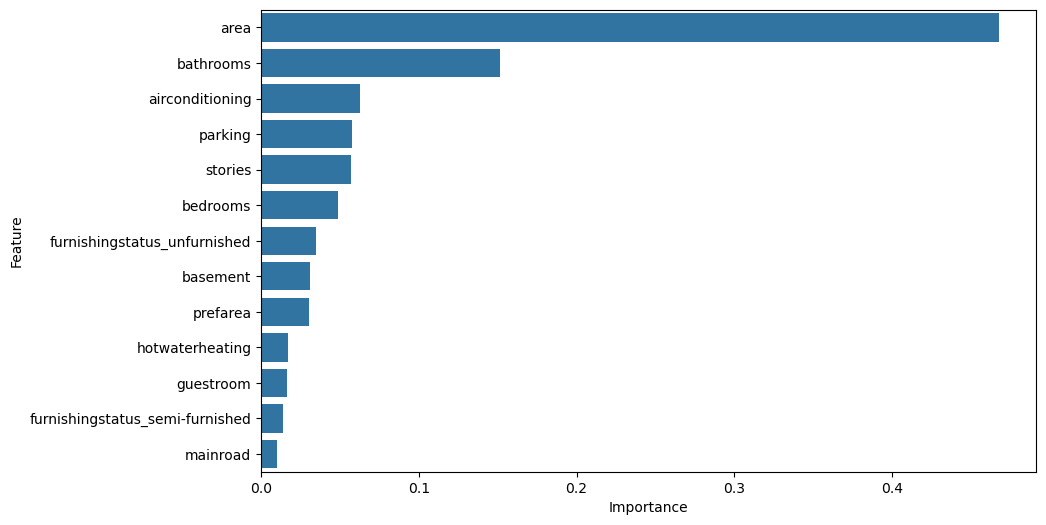

In [111]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.show()

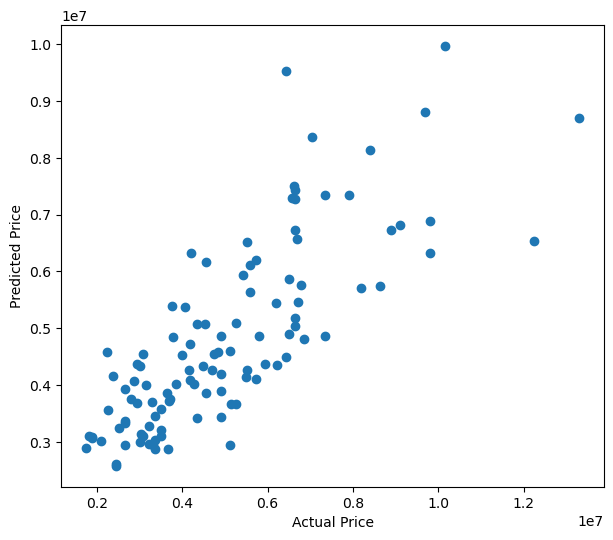

In [108]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

In [109]:
import pickle

pickle.dump(
    rf,
    open("house_price_model.pkl","wb")
)

In [110]:
model = pickle.load(
    open("house_price_model.pkl","rb")
)

In [112]:
model.predict([[5000,3,2,2,1,0,1,0,1,1,0,0,1]])

C:\Users\Windows 10 Pro\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([6869100.])

In [113]:
import os

print(os.getcwd())

C:\Users\Windows 10 Pro
